Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 306.66it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: C:\Users\roman\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 396/396 [00:01<00:00, 310.25it/s, Materializing param=visual_projection.weight]
Stab

Изображение успешно сгенерировано и сохранено как 'garage_with_car.png'


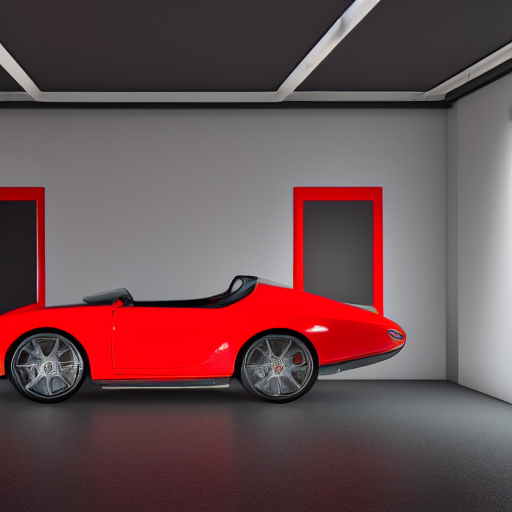

In [4]:
import torch
from diffusers import StableDiffusionPipeline, EulerDiscreteScheduler


model_id = "runwayml/stable-diffusion-v1-5"

scheduler = EulerDiscreteScheduler.from_pretrained(model_id, subfolder="scheduler")

pipe = StableDiffusionPipeline.from_pretrained(
    model_id, 
    scheduler=scheduler, 
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = pipe.to(device)

prompt = "A luxury modern garage with a classic red sports car parked inside, soft lighting, 8k resolution, photorealistic"
output_filename = "garage_with_car.png"

image = pipe(
    prompt,
    num_inference_steps=50,
    guidance_scale=8.5
).images[0]

image.save(output_filename)

print(f"Изображение успешно сгенерировано и сохранено как '{output_filename}'")
display(image)